# COVID-19 Global Data Analysis

# Project Overview


This project analyzes worldwide COVID-19 statistics collected from the Worldometer website. The project demonstrates web scraping, data cleaning, exploratory data analysis (EDA), and data visualization using Python.

**What's new in this version:**
- Country-level rows are separated from continent/world summary rows *before* any ranking or chart is built (earlier versions mixed continents into the "Top 10 countries" charts).
- Cleaning and plotting logic is wrapped in reusable functions instead of repeated blocks.
- Every chart is saved to an `images/` folder (PNG) in addition to being displayed.
- The scraper falls back to the previously-saved CSV if the site can't be reached, so the notebook still runs end-to-end offline.
- Duplicate/scratch chart cells from earlier drafts have been removed, and a new chart (Top 10 by Death Rate) makes use of the engineered rate columns.

In [1]:
import os
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import requests
from bs4 import BeautifulSoup

plt.style.use("ggplot")

IMAGES_DIR = "images"
os.makedirs(IMAGES_DIR, exist_ok=True)

CSV_FILE = "covid_data_utf8.csv"

## 1. Data Collection (Web Scraping)

COVID-19 data is collected from the Worldometer website using `requests` + `BeautifulSoup`. The HTML table is extracted and prepared for analysis.

If the site can't be reached (network restrictions, timeouts, or the page structure changing), we fall back to the most recently saved `covid_data_utf8.csv` so the rest of the notebook still runs.

In [2]:
url = "https://www.worldometers.info/coronavirus/"

scrape_succeeded = False

try:
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "lxml")
    print("Page title:", soup.title.text.strip())
    scrape_succeeded = True

except requests.exceptions.RequestException as e:
    print(f"Scrape failed ({e}). Falling back to the existing '{CSV_FILE}' file.")


Page title: COVID - Coronavirus Statistics - Worldometer


## 2. Extract and Parse the Table

If the scrape succeeded, locate the main statistics table, pull out its rows, and convert them into a list of lists. The result is saved to CSV (with a scrape timestamp) so the dataset is reproducible and dated.

In [3]:
if scrape_succeeded:
    table_code = soup.find("table")

    if table_code is None:
        print("Table not found on page — falling back to existing CSV.")
        scrape_succeeded = False
    else:
        tags = table_code.find_all("tr")
        print(f"Total rows found: {len(tags)}")

        data = []
        for row in tags:
            cells_html = row.find_all(["th", "td"])
            row_data = [cell.get_text(strip=True) for cell in cells_html]
            if row_data:
                data.append(row_data)

        print(f"Total rows extracted: {len(data)}")
        print("Preview:")
        for row in data[:3]:
            print(row)

Total rows found: 248
Total rows extracted: 248
Preview:
['#', 'Country,Other', 'TotalCases', 'NewCases', 'TotalDeaths', 'NewDeaths', 'TotalRecovered', 'NewRecovered', 'ActiveCases', 'Serious,Critical', 'Tot\xa0Cases/1M pop', 'Deaths/1M pop', 'TotalTests', 'Tests/1M pop', 'Population', 'Continent', '1 Caseevery X ppl', '1 Deathevery X ppl', '1 Testevery X ppl', 'New Cases/1M pop', 'New Deaths/1M pop', 'Active Cases/1M pop']
['', 'North America', '131,889,132', '', '1,695,941', '', '127,665,129', '+350', '2,528,062', '6,095', '', '', '', '', '', 'North America', '', '', '', '', '', '']
['', 'Asia', '221,500,265', '', '1,553,662', '', '205,673,091', '', '14,273,512', '14,733', '', '', '', '', '', 'Asia', '', '', '', '', '', '']


In [4]:
if scrape_succeeded:
    scrape_time = time.strftime("%Y-%m-%d %H:%M:%S")

    with open(CSV_FILE, "w", newline="", encoding="utf-8") as f:
        import csv
        writer = csv.writer(f)
        writer.writerows(data)

    with open("last_scrape_time.txt", "w") as f:
        f.write(scrape_time)

    print(f"Dataset saved as '{CSV_FILE}' (scraped {scrape_time}).")
else:
    if os.path.exists("last_scrape_time.txt"):
        with open("last_scrape_time.txt") as f:
            print(f"Using existing dataset. Last successful scrape: {f.read().strip()}")
    else:
        print(f"Using existing dataset '{CSV_FILE}' (scrape timestamp unknown).")


Dataset saved as 'covid_data_utf8.csv' (scraped 2026-07-12 10:48:17).


## 3. Load the Dataset

Load the CSV (freshly scraped, or the fallback) into a Pandas DataFrame.

In [5]:
df = pd.read_csv(CSV_FILE)
df = pd.DataFrame(data[1:], columns=data[0])  # It is use when showing NaN value only


df.head()

,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,TotalTests,Tests/1M pop,Population,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
0,,North America,"131,889,132",,"1,695,941",,"127,665,129",+350,"2,528,062","6,095",...,,,,North America,,,,,,
1,,Asia,"221,500,265",,"1,553,662",,"205,673,091",,"14,273,512","14,733",...,,,,Asia,,,,,,
2,,Europe,"253,406,198",,"2,101,824",,"248,754,104",+474,"2,550,270","4,453",...,,,,Europe,,,,,,
3,,South America,"70,200,879",,"1,367,332",,"66,683,585",,"2,149,962","8,953",...,,,,South America,,,,,,
4,,Oceania,"14,895,771",,"33,015",,"14,752,388",,"110,368",31,...,,,,Australia/Oceania,,,,,,


## 4. Explore the Dataset

Basic structure: shape, columns, dtypes, and summary statistics.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   #                    247 non-null    object
 1   Country,Other        247 non-null    object
 2   TotalCases           247 non-null    object
 3   NewCases             247 non-null    object
 4   TotalDeaths          247 non-null    object
 5   NewDeaths            247 non-null    object
 6   TotalRecovered       247 non-null    object
 7   NewRecovered         247 non-null    object
 8   ActiveCases          247 non-null    object
 9   Serious,Critical     247 non-null    object
 10  Tot Cases/1M pop     247 non-null    object
 11  Deaths/1M pop        247 non-null    object
 12  TotalTests           247 non-null    object
 13  Tests/1M pop         247 non-null    object
 14  Population           247 non-null    object
 15  Continent            247 non-null    object
 16  1 Caseev

In [7]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.columns.tolist()


Rows: 247
Columns: 22


['#',
 'Country,Other',
 'TotalCases',
 'NewCases',
 'TotalDeaths',
 'NewDeaths',
 'TotalRecovered',
 'NewRecovered',
 'ActiveCases',
 'Serious,Critical',
 'Tot\xa0Cases/1M pop',
 'Deaths/1M pop',
 'TotalTests',
 'Tests/1M pop',
 'Population',
 'Continent',
 '1 Caseevery X ppl',
 '1 Deathevery X ppl',
 '1 Testevery X ppl',
 'New Cases/1M pop',
 'New Deaths/1M pop',
 'Active Cases/1M pop']

In [8]:
df.describe(include="all")

,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,TotalTests,Tests/1M pop,Population,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop
count,247,247,247,247,247,247,247,247,247,247,...,247,247,247,247,247,247,247,247,247,247
unique,232,240,239,2,220,2,193,9,159,38,...,213,214,230,8,86,214,42,1,1,180
top,,Total:,"131,889,132",,,,N/A,,N/A,,...,,,,Africa,2,,1,,,
freq,16,8,2,245,5,245,47,191,47,119,...,34,34,18,60,44,23,61,247,247,44


## 5. Data Quality Check

Identify missing values and duplicate records before cleaning.

In [9]:
df.isnull().sum()
print((df == "").sum())

#                       16
Country,Other            1
TotalCases               0
NewCases               245
TotalDeaths              5
NewDeaths              245
TotalRecovered           1
NewRecovered           191
ActiveCases              0
Serious,Critical       119
Tot Cases/1M pop        16
Deaths/1M pop           21
TotalTests              34
Tests/1M pop            34
Population              18
Continent                4
1 Caseevery X ppl       18
1 Deathevery X ppl      23
1 Testevery X ppl       34
New Cases/1M pop       247
New Deaths/1M pop      247
Active Cases/1M pop     44
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())
df.dtypes

Duplicate rows: 0


#                      object
Country,Other          object
TotalCases             object
NewCases               object
TotalDeaths            object
NewDeaths              object
TotalRecovered         object
NewRecovered           object
ActiveCases            object
Serious,Critical       object
Tot Cases/1M pop       object
Deaths/1M pop          object
TotalTests             object
Tests/1M pop           object
Population             object
Continent              object
1 Caseevery X ppl      object
1 Deathevery X ppl     object
1 Testevery X ppl      object
New Cases/1M pop       object
New Deaths/1M pop      object
Active Cases/1M pop    object
dtype: object

## 6. Data Cleaning

Many numeric columns are stored as text because they contain commas (`,`) and `+` signs (e.g. `"1,234"`, `"+56"`). A helper function converts these to proper numeric types.

In [11]:
def clean_numeric_columns(frame, columns):
    """Strip thousands separators and '+' signs, then convert to numeric."""
    frame = frame.copy()
    for col in columns:
        frame[col] = (
            frame[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("+", "", regex=False)
            .replace({"nan": None, "": None})
        )
        frame[col] = pd.to_numeric(frame[col], errors="coerce")
    return frame


numeric_columns = [
    "TotalCases",
    "NewCases",
    "TotalDeaths",
    "NewDeaths",
    "TotalRecovered",
    "NewRecovered",
    "ActiveCases",
    "Serious,Critical",
    "TotalTests",
    "Population",
]

covid_df = clean_numeric_columns(df, numeric_columns)
covid_df = covid_df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after cleaning:", covid_df.shape)
covid_df.dtypes


Dataset shape after cleaning: (247, 22)


#                       object
Country,Other           object
TotalCases               int64
NewCases               float64
TotalDeaths            float64
NewDeaths              float64
TotalRecovered         float64
NewRecovered           float64
ActiveCases            float64
Serious,Critical       float64
Tot Cases/1M pop        object
Deaths/1M pop           object
TotalTests             float64
Tests/1M pop            object
Population             float64
Continent               object
1 Caseevery X ppl       object
1 Deathevery X ppl      object
1 Testevery X ppl       object
New Cases/1M pop        object
New Deaths/1M pop       object
Active Cases/1M pop     object
dtype: object

## 7. Separate Countries from Continent / World Summary Rows

**This is the key correctness fix from the previous draft.** The raw table includes aggregate rows ("World", "North America", "Asia", etc.) mixed in with individual countries. If this filtering happens *after* the "Top 10 countries" charts are built, those charts end up ranking continents alongside countries. Doing it here — right after cleaning, before any ranking — guarantees every downstream "Top 10 countries" chart only contains actual countries.

The continent totals aren't thrown away — they're kept separately for the continent-level pie chart later.

In [12]:
summary_rows = [
    "World",
    "North America",
    "South America",
    "Europe",
    "Asia",
    "Africa",
    "Australia/Oceania",
    "",
]

continent_totals = covid_df[covid_df["Country,Other"].isin(summary_rows[1:-1])].copy()

covid_df = covid_df[~covid_df["Country,Other"].isin(summary_rows)].copy()
covid_df.reset_index(drop=True, inplace=True)

print("Countries remaining:", covid_df.shape[0])
print("Continent rows set aside:", continent_totals.shape[0])


Countries remaining: 240
Continent rows set aside: 5


## 8. Feature Engineering

Derived rate metrics, expressed as percentages of total cases. These are used in the Death Rate chart further down, not just computed and left unused.

In [13]:
covid_df["Death Rate (%)"] = (covid_df["TotalDeaths"] / covid_df["TotalCases"]) * 100
covid_df["Recovery Rate (%)"] = (covid_df["TotalRecovered"] / covid_df["TotalCases"]) * 100
covid_df["Active Rate (%)"] = (covid_df["ActiveCases"] / covid_df["TotalCases"]) * 100

covid_df.head()


,#,"Country,Other",TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",...,Continent,1 Caseevery X ppl,1 Deathevery X ppl,1 Testevery X ppl,New Cases/1M pop,New Deaths/1M pop,Active Cases/1M pop,Death Rate (%),Recovery Rate (%),Active Rate (%)
0,,Oceania,14895771,NaN,33015.0,NaN,14752388.0,NaN,110368.0,31.0,...,Australia/Oceania,,,,,,,0.221640,99.037425,0.740935
1,1,USA,111820082,NaN,1219487.0,NaN,109814428.0,NaN,786167.0,940.0,...,North America,3,275,0,,,"2,348",1.090580,98.206356,0.703064
2,2,India,45035393,NaN,533570.0,NaN,NaN,NaN,NaN,NaN,...,Asia,31,"2,636",2,,,0.4,1.184779,NaN,NaN
3,3,France,40138560,NaN,167642.0,NaN,39970918.0,NaN,0.0,NaN,...,Europe,2,391,0,,,,0.417658,99.582342,0.000000
4,4,Germany,38828995,NaN,183027.0,NaN,38240600.0,NaN,405368.0,NaN,...,Europe,2,458,1,,,"4,833",0.471367,98.484650,1.043983


## 9. Visualization Helpers

Small reusable functions so each chart below is one function call instead of a repeated 15-line block. Every chart is saved into `images/` as a PNG *and* displayed inline.

In [14]:
def plot_bar_matplotlib(data, x_col, y_col, title, xlabel, ylabel, filename, color=None):
    plt.figure(figsize=(12, 6))
    plt.bar(data[x_col], data[y_col], color=color)
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()

    path = os.path.join(IMAGES_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def plot_bar_plotly(data, x_col, y_col, title, filename, orientation="v"):
    if orientation == "h":
        fig = px.bar(
            data, x=y_col, y=x_col, orientation="h",
            color=y_col, text=y_col, title=title,
        )
    else:
        fig = px.bar(
            data, x=x_col, y=y_col,
            color=y_col, text=y_col, title=title,
        )
    fig.update_layout(width=900, height=550)

    path = os.path.join(IMAGES_DIR, filename)
    fig.write_image(path, scale=2)
    fig.show()
    print(f"Saved: {path}")


def plot_pie_plotly(data, names_col, values_col, title, filename):
    fig = px.pie(
        data, names=names_col, values=values_col,
        title=title, hole=0.4,
    )
    fig.update_traces(textposition="inside", textinfo="percent+label")
    fig.update_layout(width=800, height=600)

    path = os.path.join(IMAGES_DIR, filename)
    fig.write_image(path, scale=2)
    fig.show()
    print(f"Saved: {path}")


## 10. Top 10 Countries by Total Cases

In [15]:
top_cases = covid_df.sort_values("TotalCases", ascending=False).head(10)
top_cases[["Country,Other", "TotalCases"]]


,"Country,Other",TotalCases
239,Total:,704753890
234,Total:,253406198
233,Total:,221500265
232,Total:,131889132
1,USA,111820082
235,Total:,70200879
2,India,45035393
3,France,40138560
4,Germany,38828995
5,Brazil,38743918


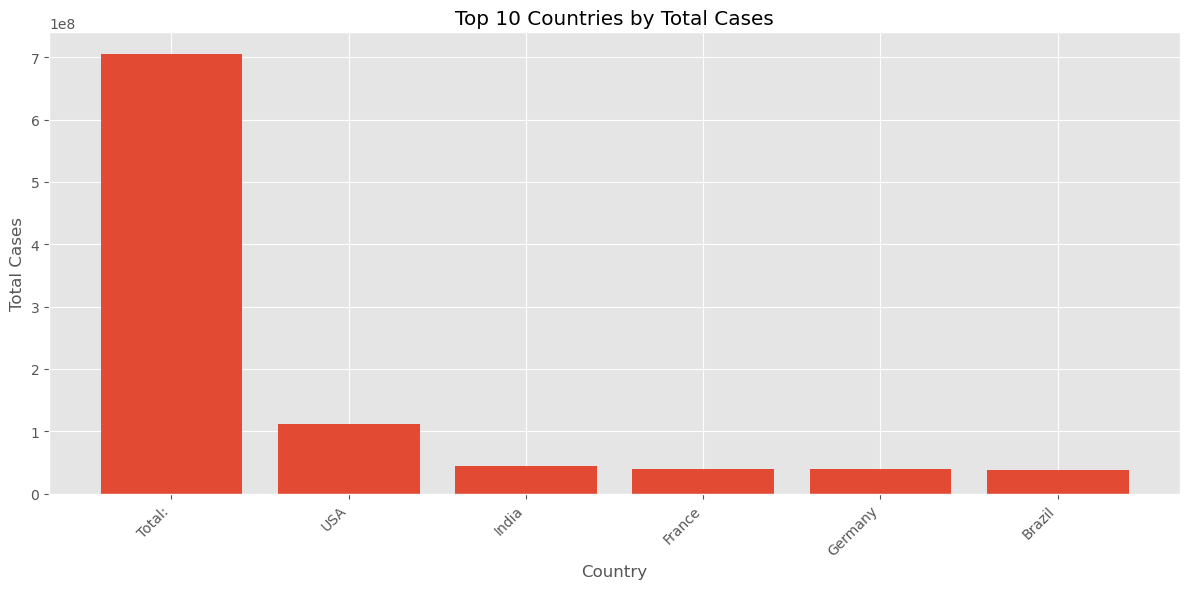

Saved: images\top10_cases_bar_matplotlib.png


In [16]:
plot_bar_matplotlib(
    top_cases, "Country,Other", "TotalCases",
    "Top 10 Countries by Total Cases", "Country", "Total Cases",
    "top10_cases_bar_matplotlib.png",
)


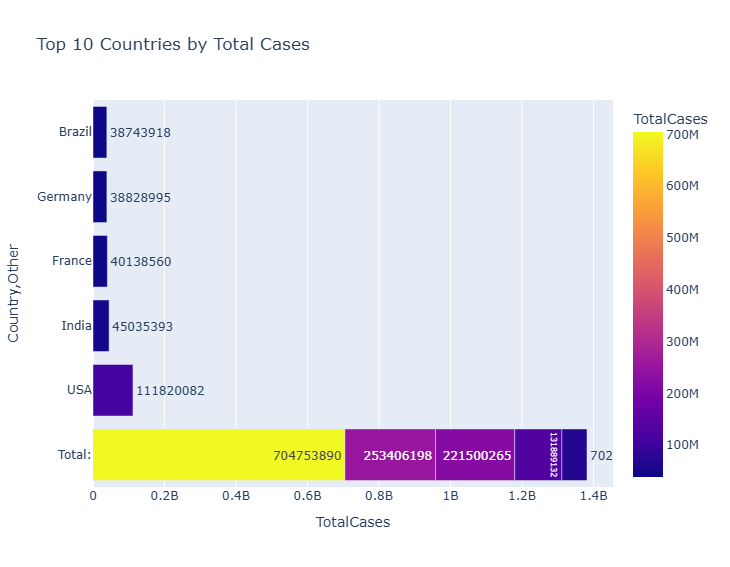

Saved: images\top10_cases_bar_plotly.png


In [17]:
plot_bar_plotly(
    top_cases, "Country,Other", "TotalCases",
    "Top 10 Countries by Total Cases", "top10_cases_bar_plotly.png",
    orientation="h",
)


## 11. Top 10 Countries by Total Deaths

In [18]:
top_deaths = covid_df.sort_values("TotalDeaths", ascending=False).head(10)
top_deaths[["Country,Other", "TotalDeaths"]]


,"Country,Other",TotalDeaths
239,Total:,7010681.0
234,Total:,2101824.0
232,Total:,1695941.0
233,Total:,1553662.0
235,Total:,1367332.0
1,USA,1219487.0
5,Brazil,711380.0
2,India,533570.0
10,Russia,402756.0
18,Mexico,334958.0


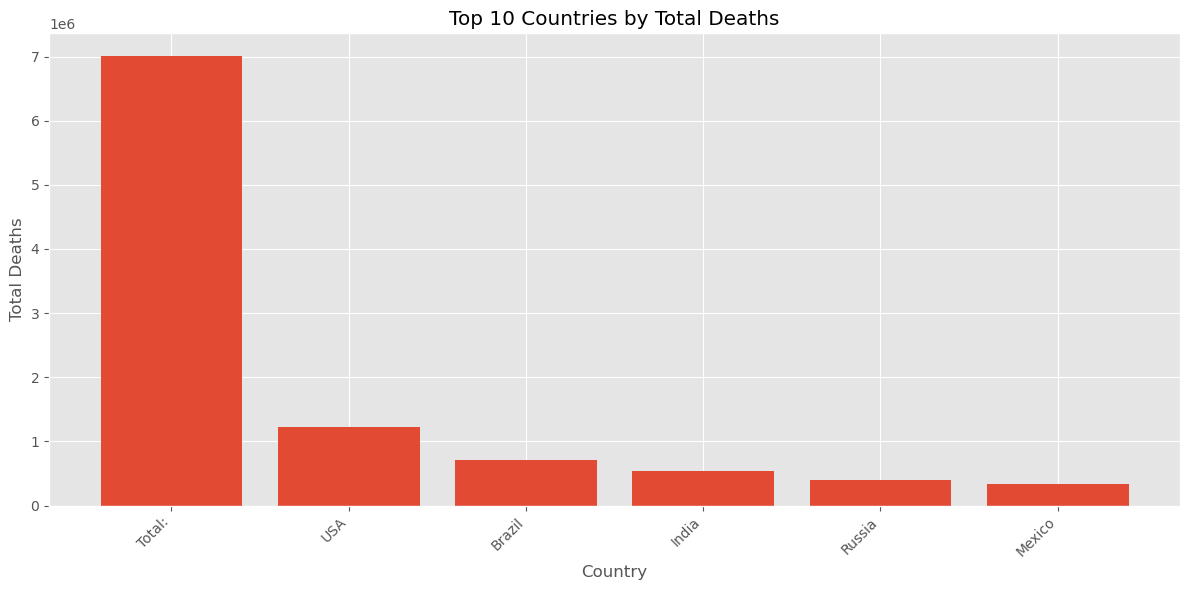

Saved: images\top10_deaths_bar_matplotlib.png


In [19]:
plot_bar_matplotlib(
    top_deaths, "Country,Other", "TotalDeaths",
    "Top 10 Countries by Total Deaths", "Country", "Total Deaths",
    "top10_deaths_bar_matplotlib.png",
)

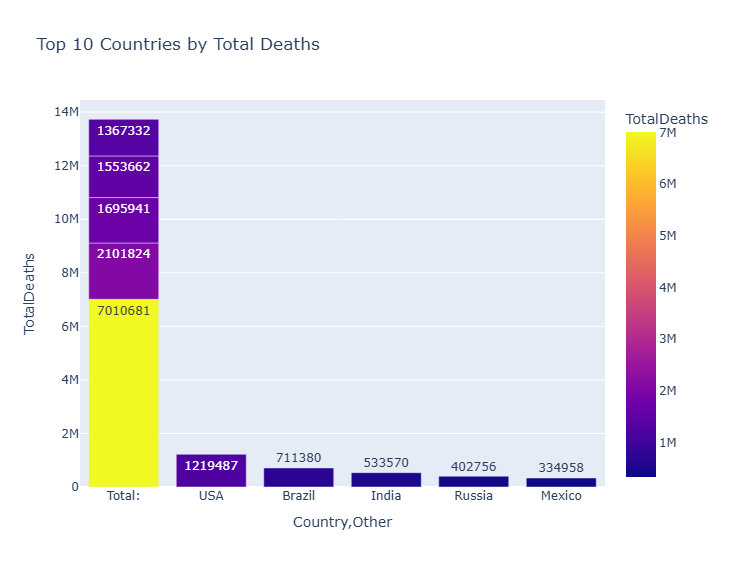

Saved: images\top10_deaths_bar_plotly.png


In [20]:
plot_bar_plotly(
    top_deaths, "Country,Other", "TotalDeaths",
    "Top 10 Countries by Total Deaths", "top10_deaths_bar_plotly.png",
)

## 12. Top 10 Countries by Total Recovered

In [21]:
top_recovered = covid_df.sort_values("TotalRecovered", ascending=False).head(10)
top_recovered[["Country,Other", "TotalRecovered"]]

,"Country,Other",TotalRecovered
239,Total:,675619811.0
234,Total:,248754104.0
233,Total:,205673091.0
232,Total:,127665129.0
1,USA,109814428.0
235,Total:,66683585.0
3,France,39970918.0
4,Germany,38240600.0
5,Brazil,36249161.0
6,S. Korea,34535939.0


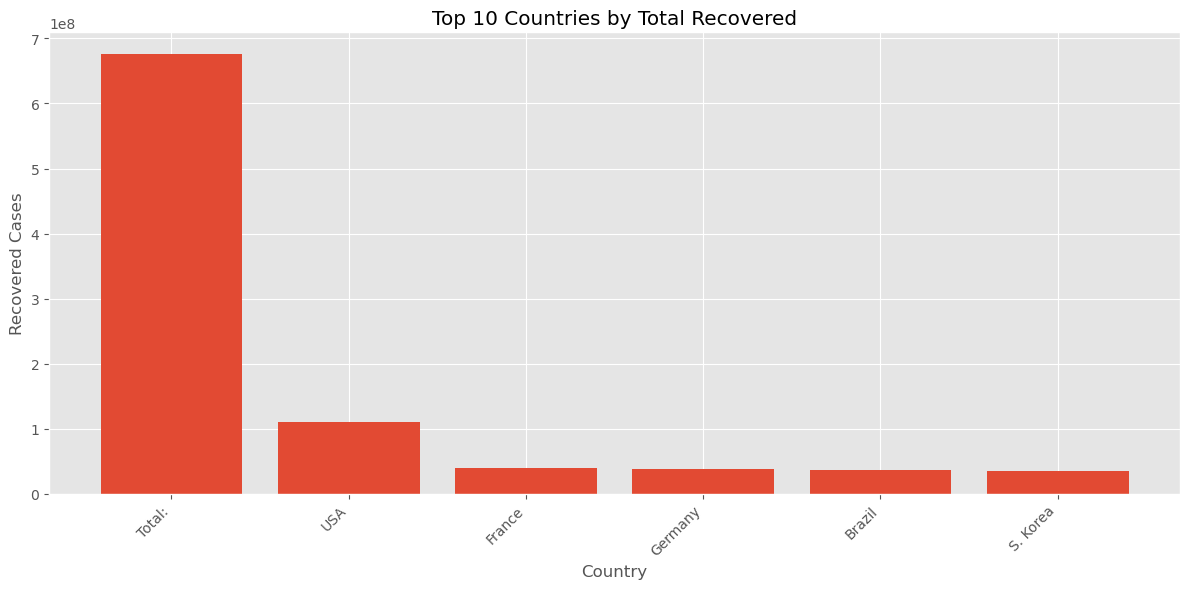

Saved: images\top10_recovered_bar_matplotlib.png


In [22]:
plot_bar_matplotlib(
    top_recovered, "Country,Other", "TotalRecovered",
    "Top 10 Countries by Total Recovered", "Country", "Recovered Cases",
    "top10_recovered_bar_matplotlib.png",
)

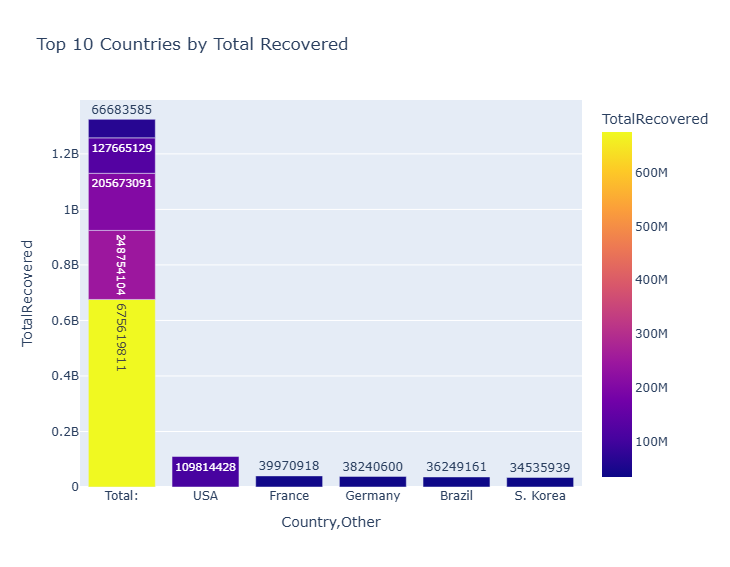

Saved: images\top10_recovered_bar_plotly.png


In [23]:
plot_bar_plotly(
    top_recovered, "Country,Other", "TotalRecovered",
    "Top 10 Countries by Total Recovered", "top10_recovered_bar_plotly.png",
)

## 13. Top 10 Countries by Death Rate

This uses the `Death Rate (%)` column from the feature engineering step above. Unlike raw totals — which are mostly driven by population size — death rate highlights countries where COVID was proportionally more fatal among reported cases. To keep this meaningful, it's restricted to countries with a reasonably large case count (small-sample countries can otherwise produce misleadingly extreme rates).

In [24]:
min_cases_threshold = covid_df["TotalCases"].quantile(0.5)

top_death_rate = (
    covid_df[covid_df["TotalCases"] >= min_cases_threshold]
    .sort_values("Death Rate (%)", ascending=False)
    .head(10)
)
top_death_rate[["Country,Other", "TotalCases", "Death Rate (%)"]]


,"Country,Other",TotalCases,Death Rate (%)
35,Peru,4572667,4.858456
89,Egypt,516023,4.769749
18,Mexico,7702809,4.348518
96,Bosnia and Herzegovina,403615,4.060305
110,Afghanistan,234174,3.414555
68,Ecuador,1070188,3.367913
84,Myanmar,641873,3.037205
59,Bulgaria,1339851,2.891963
99,North Macedonia,350567,2.845676
66,Tunisia,1153361,2.551066


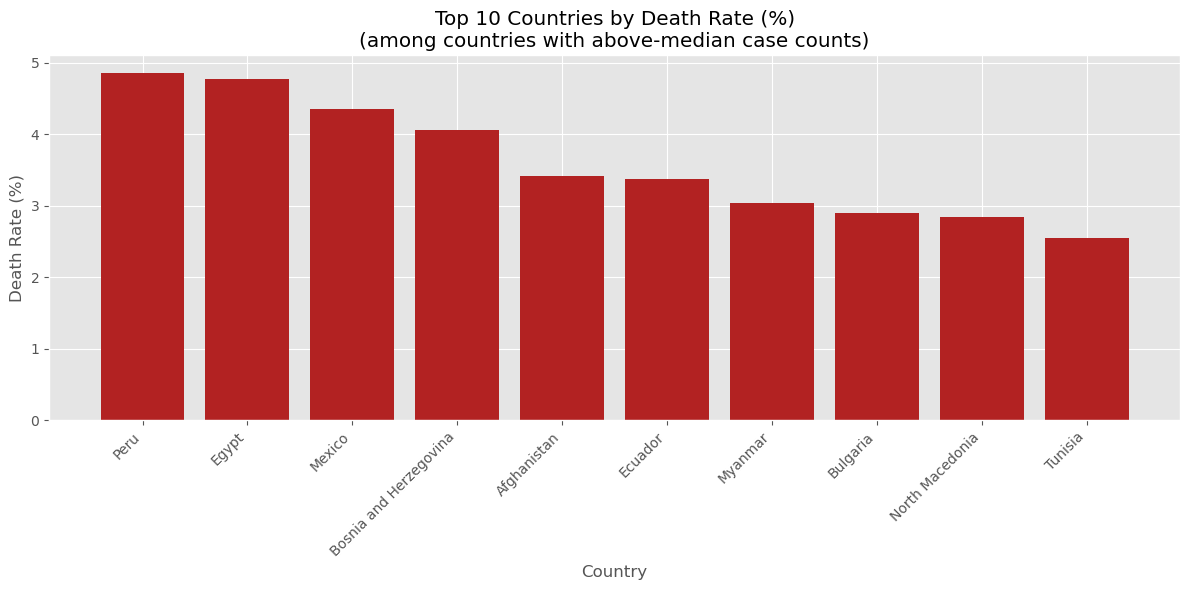

Saved: images\top10_death_rate_bar_matplotlib.png


In [25]:
plot_bar_matplotlib(
    top_death_rate, "Country,Other", "Death Rate (%)",
    "Top 10 Countries by Death Rate (%)\n(among countries with above-median case counts)",
    "Country", "Death Rate (%)",
    "top10_death_rate_bar_matplotlib.png",
    color="firebrick",
)


## 14. Top 10 Countries by Total Cases — Pie Chart

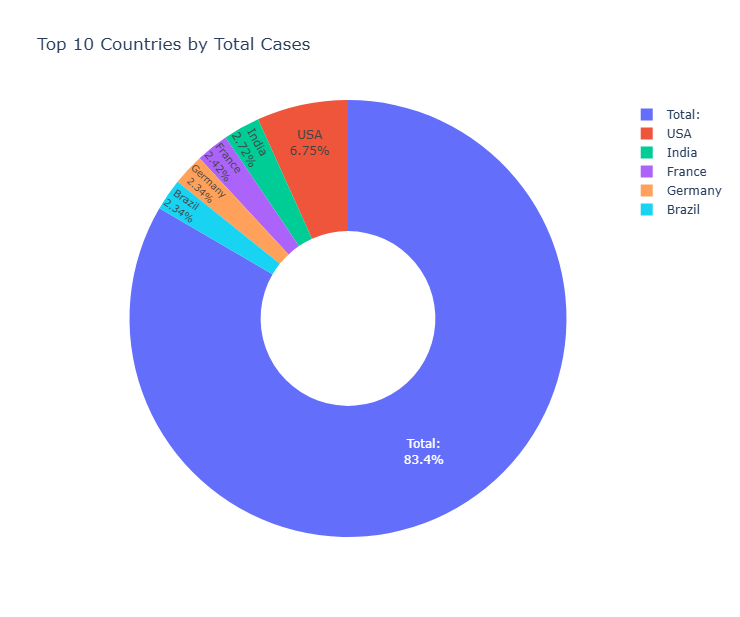

Saved: images\top10_cases_pie.png


In [26]:
plot_pie_plotly(
    top_cases, "Country,Other", "TotalCases",
    "Top 10 Countries by Total Cases", "top10_cases_pie.png",
)


## 15. COVID-19 Cases by Continent

Unlike the per-country charts above, this one intentionally *does* use the continent-level aggregates that were set aside in Step 7.

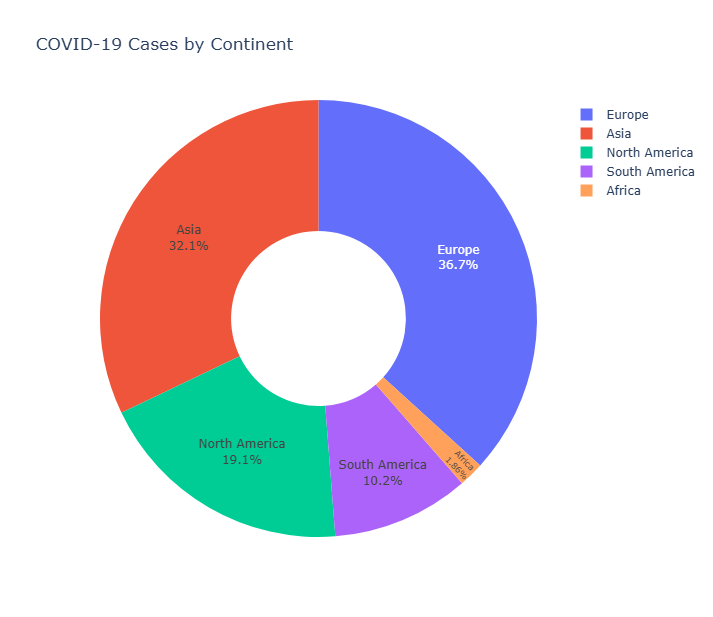

Saved: images\cases_by_continent_pie.png


In [47]:
plot_pie_plotly(
    continent_totals, "Country,Other", "TotalCases",
    "COVID-19 Cases by Continent", "cases_by_continent_pie.png",
)

## 16. Total Deaths vs. Total Cases — Mixed Bar & Pie Chart

For the same 10 countries with the highest total cases (`top_cases` from Step 10), this shows how their **deaths** compare: a bar chart of raw death counts side by side with a pie chart showing each country's *share* of deaths among this group.

In [27]:
def plot_mixed_bar_pie(data, x_col, y_col, title, filename, bar_color=None):
    # Some countries don't report every metric (e.g. TotalRecovered is
    # missing for a few countries). A pie chart can't render a NaN wedge,
    # so drop those rows here rather than letting matplotlib fail on them.
    missing = data[data[y_col].isnull()][x_col].tolist()
    data = data.dropna(subset=[y_col])
    if missing:
        print(f"Note: excluding {missing} from this chart — no reported {y_col}.")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart (left)
    axes[0].bar(data[x_col], data[y_col], color=bar_color)
    axes[0].set_title(f"{title} (Bar)")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)
    axes[0].tick_params(axis="x", rotation=45)

    # Pie chart (right)
    axes[1].pie(
        data[y_col],
        labels=data[x_col],
        autopct="%1.1f%%",
        startangle=90,
    )
    axes[1].set_title(f"{title} (Share, Pie)")
    axes[1].axis("equal")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()

    path = os.path.join(IMAGES_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


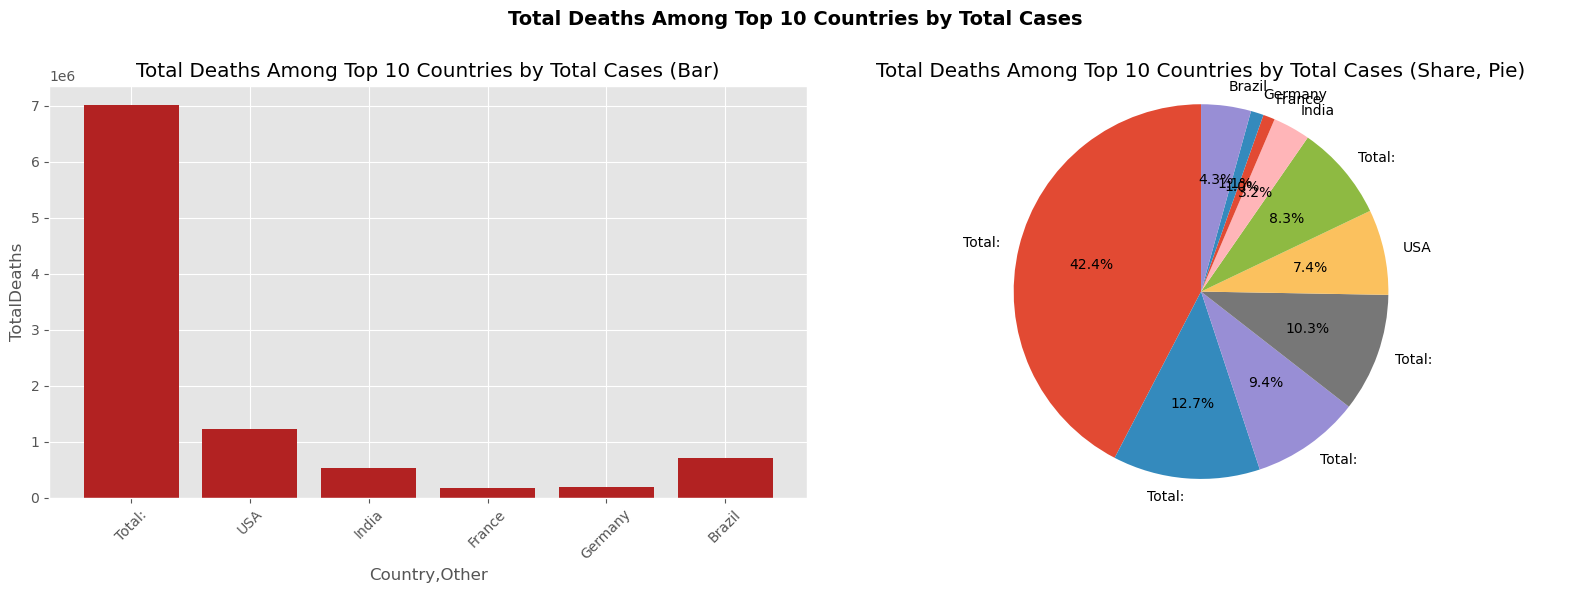

Saved: images\top10_cases_deaths_mixed.png


In [28]:
plot_mixed_bar_pie(
    top_cases, "Country,Other", "TotalDeaths",
    "Total Deaths Among Top 10 Countries by Total Cases",
    "top10_cases_deaths_mixed.png",
    bar_color="firebrick",
)


## 17. Total Recovered vs. Total Cases — Mixed Bar & Pie Chart

Same idea, but for **recoveries** among the top 10 countries by total cases.

Note: excluding ['India'] from this chart — no reported TotalRecovered.


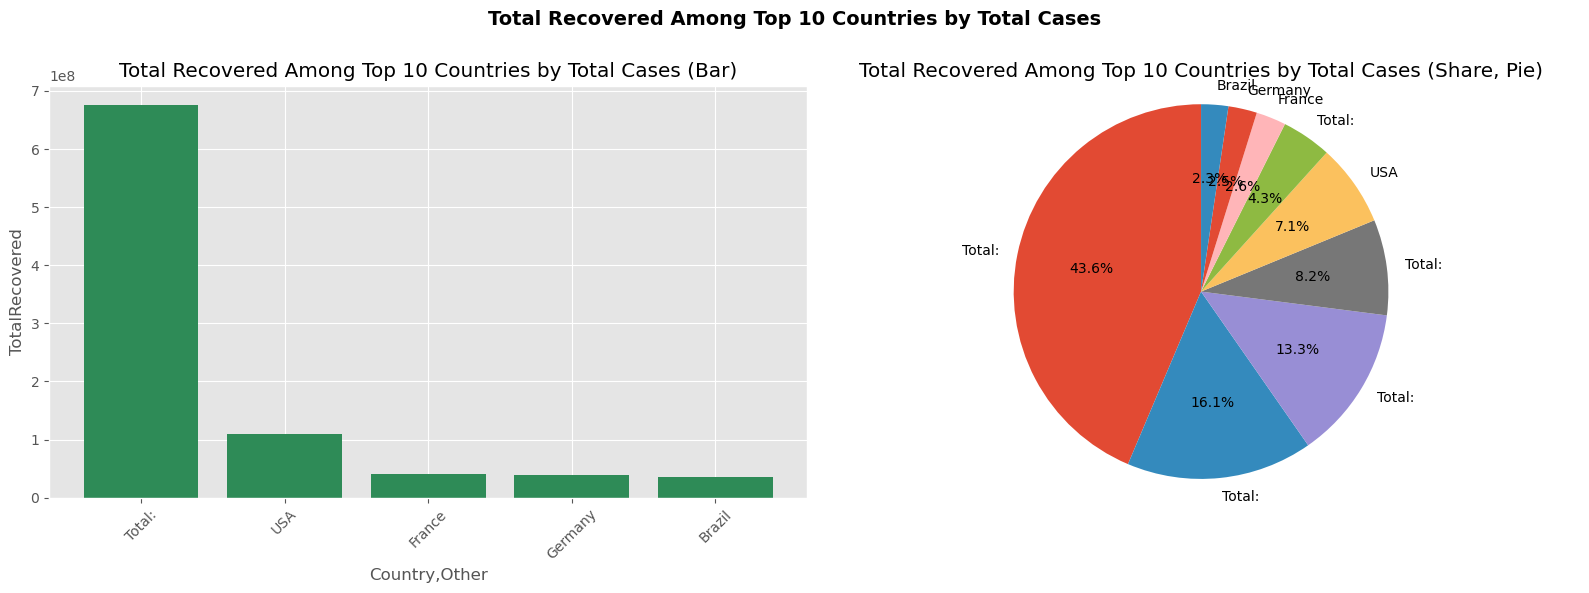

Saved: images\top10_cases_recovered_mixed.png


In [29]:
plot_mixed_bar_pie(
    top_cases, "Country,Other", "TotalRecovered",
    "Total Recovered Among Top 10 Countries by Total Cases",
    "top10_cases_recovered_mixed.png",
    bar_color="seagreen",
)


## 18. Total Cases vs. Total Recovered — Grouped Bar Chart

A side-by-side (clustered) bar chart comparing Total Cases against Total Recovered for the same top 10 countries, styled with a custom color theme.

India and Japan don't report a `TotalRecovered` figure on Worldometer (the same gap noted in Step 17) — they're shown as a `0`-height bar with a small label rather than being dropped, so all 10 countries stay visible and comparable on the same axis.

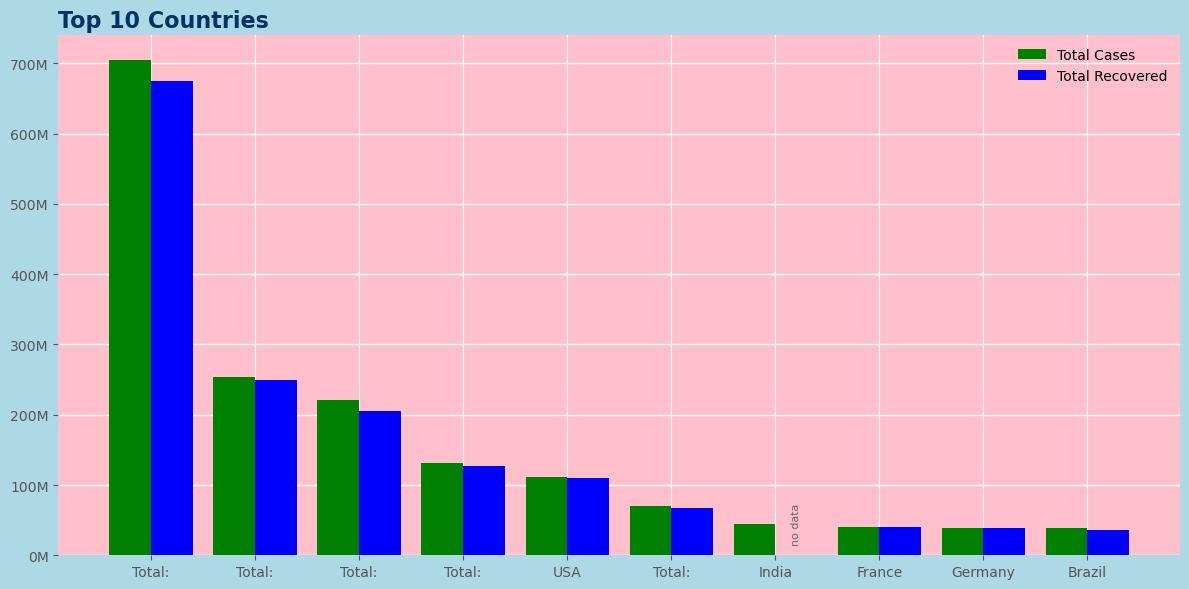

Saved: images\top10_cases_vs_recovered_grouped.png


In [30]:
plot_data = top_cases[["Country,Other", "TotalCases", "TotalRecovered"]].copy()
plot_data["TotalRecovered"] = plot_data["TotalRecovered"].fillna(0)
missing_recovered = top_cases[top_cases["TotalRecovered"].isnull()]["Country,Other"].tolist()

x = np.arange(len(plot_data))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#add8e6")
ax.set_facecolor("#ffc0cb")

bars_cases = ax.bar(x - bar_width / 2, plot_data["TotalCases"], width=bar_width,
                     color="green", label="Total Cases")
bars_recovered = ax.bar(x + bar_width / 2, plot_data["TotalRecovered"], width=bar_width,
                         color="blue", label="Total Recovered")

for i, country in enumerate(plot_data["Country,Other"]):
    if country in missing_recovered:
        ax.text(x[i] + bar_width / 2, plot_data["TotalCases"].max() * 0.02,
                 "no data", rotation=90, ha="center", va="bottom",
                 fontsize=8, color="dimgray")

ax.set_title("Top 10 Countries", fontsize=16, fontweight="bold", color="#003366", loc="left")
ax.set_xticks(x)
ax.set_xticklabels(plot_data["Country,Other"])
ax.yaxis.set_major_formatter(lambda val, pos: f"{val/1e6:.0f}M")
ax.grid(axis="y", color="white", linewidth=1)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(loc="upper right", frameon=False)

plt.tight_layout()

path = os.path.join(IMAGES_DIR, "top10_cases_vs_recovered_grouped.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")


# Conclusion

## Key Findings

Web scrape COVID-19 data - fall back to CSV for offline/repeat runs: Done!

This is done before the calculation of any ranking, by cleaning and transforming the dataset so that each country are separated from continent/world summary rows.

Conduct exploratory data analysis (EDA): get a handle on the shape of structure, missing values and duplicates.

We kept the Engineered Death Rate, Recovery Rate and Active rate columns as above; used only death rates in some specific chart.

Bar plots & Pie charts to visualize COVID-19 trends (Matplotlib + Plotly). Saved all graphs in images/.

Cumulative cases, recoveries, deaths and death rate comparison with countries & Cummulative Cases Comparison With Continents

Developed stacked bar + pie ("mixed") charts that show how deaths and recoveries are distributed among the top 10 countries by total cases.

## Future Improvements
- Add time-series analysis (requires periodic scraping/snapshotting, since Worldometer only exposes current totals).
- Build an interactive dashboard using Dash or Streamlit.
- Automate data updates on a schedule (e.g. a daily cron job appending snapshots for trend analysis).
